# TAHAP 02 — Dataset Validation, Error Analysis, Threshold Tuning, dan Evaluasi Kinerja Chatbot

Notebook ini melanjutkan baseline chatbot FAQ berbasis **TF-IDF** dan **Cosine Similarity** dari Tahap 01. Fokus utama Tahap 02 adalah memastikan dataset FAQ dan dataset evaluasi layak digunakan, mengidentifikasi pertanyaan yang gagal, melakukan tuning threshold, serta menyusun rekomendasi perbaikan chatbot.

> Catatan: hasil evaluasi pada notebook ini masih bersifat awal karena jumlah pertanyaan uji masih terbatas. Nilai akurasi tidak bisa diklaim sebagai performa final sebelum jumlah dan variasi pertanyaan evaluasi diperluas.

## 1. Import Library dan Setup Path

Bagian ini menyiapkan library yang digunakan untuk validasi dataset, TF-IDF, cosine similarity, evaluasi, threshold tuning, dan visualisasi.


In [1]:
from pathlib import Path
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import confusion_matrix, classification_report

pd.set_option('display.max_colwidth', 120)
pd.set_option('display.max_columns', 50)

# Path notebook: project_root/notebooks/02_...
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
DATA_DIR = PROJECT_ROOT / 'data'
OUTPUT_DIR = PROJECT_ROOT / 'outputs' / 'stage02'
FIGURE_DIR = OUTPUT_DIR / 'figures'

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

FAQ_PATH = DATA_DIR / 'faq_mti_unpam.csv'
EVAL_PATH = DATA_DIR / 'evaluation_questions.csv'

print('PROJECT_ROOT:', PROJECT_ROOT)
print('FAQ_PATH:', FAQ_PATH)
print('EVAL_PATH:', EVAL_PATH)

PROJECT_ROOT: D:\DATA-KAMIL\MATKUL\SEMESTER-1\DATA-MINING\TUGAS\TUGAS-21\mti-unpam-academic-chatbot
FAQ_PATH: D:\DATA-KAMIL\MATKUL\SEMESTER-1\DATA-MINING\TUGAS\TUGAS-21\mti-unpam-academic-chatbot\data\faq_mti_unpam.csv
EVAL_PATH: D:\DATA-KAMIL\MATKUL\SEMESTER-1\DATA-MINING\TUGAS\TUGAS-21\mti-unpam-academic-chatbot\data\evaluation_questions.csv


## 2. Load Dataset FAQ dan Dataset Evaluasi

Dataset FAQ digunakan sebagai knowledge base sederhana. Dataset evaluasi digunakan untuk mengukur apakah chatbot mampu mengembalikan kategori jawaban yang sesuai dengan ekspektasi.

In [2]:
faq_df = pd.read_csv(FAQ_PATH).fillna('')
eval_df = pd.read_csv(EVAL_PATH).fillna('')

print('Shape FAQ:', faq_df.shape)
print('Shape Evaluation:', eval_df.shape)

display(faq_df.head())
display(eval_df)

Shape FAQ: (34, 6)
Shape Evaluation: (7, 2)


,question,answer,category,semester,peminatan,source_type
0,Apa itu Program Magister Teknik Informatika UNPAM?,Program Magister Teknik Informatika UNPAM adalah program pascasarjana bidang informatika yang berfokus pada penguata...,profil_program,,,manual
1,Apa tujuan chatbot MTI UNPAM Academic Assistant?,Chatbot ini dibuat sebagai media bantu informasi akademik agar calon mahasiswa lebih mudah memahami struktur perkuli...,profil_program,,,manual
2,Apa saja mata kuliah Semester 1 MTI UNPAM?,"Mata kuliah Semester I terdiri dari Algoritma Analisis, Data Mining, Modelling and Optimization, serta Sistem Komput...",kurikulum_semester_1,1.0,,user_provided
3,Apa yang dipelajari pada Algoritma Analisis?,"Algoritma Analisis membahas konsep perancangan, analisis kompleksitas, dan evaluasi algoritma untuk menyelesaikan ma...",kurikulum_semester_1,1.0,,manual
4,Apa yang dipelajari pada Data Mining?,"Data Mining membahas proses menemukan pola, hubungan, atau pengetahuan dari data melalui preprocessing, eksplorasi d...",kurikulum_semester_1,1.0,,manual


,test_question,expected_category
0,Mata kuliah semester satu apa saja?,kurikulum_semester_1
1,Kalau saya suka cyber security cocoknya peminatan apa?,rekomendasi_peminatan
2,Peminatan data science belajar apa?,peminatan_data_science
3,Apa perbedaan IoT dan data science?,rekomendasi_peminatan
4,Semester empat ada mata kuliah apa?,kurikulum_semester_4
5,"Saya suka memasak nasi goreng, apa resepnya?",fallback
6,Berapa harga biaya kuliah terbaru?,fallback


## 3. Validasi Kualitas Dataset FAQ

Validasi dilakukan untuk memeriksa kolom wajib, data kosong, duplikasi, jumlah kategori, dan keseimbangan jumlah FAQ per kategori.

In [3]:
REQUIRED_FAQ_COLUMNS = ['question', 'answer', 'category', 'semester', 'peminatan', 'source_type']

def validate_faq_dataset(df: pd.DataFrame) -> pd.DataFrame:
    checks = []
    missing_columns = [col for col in REQUIRED_FAQ_COLUMNS if col not in df.columns]
    checks.append({
        'check': 'required_columns',
        'status': 'PASS' if not missing_columns else 'FAIL',
        'detail': str(missing_columns)
    })

    if missing_columns:
        return pd.DataFrame(checks)

    empty_question = int((df['question'].astype(str).str.strip() == '').sum())
    empty_answer = int((df['answer'].astype(str).str.strip() == '').sum())
    duplicate_question = int(df['question'].astype(str).str.lower().str.strip().duplicated().sum())
    duplicate_answer = int(df['answer'].astype(str).str.lower().str.strip().duplicated().sum())
    category_counts = df['category'].value_counts()
    min_category_count = int(category_counts.min()) if len(category_counts) else 0

    checks.extend([
        {'check': 'total_rows', 'status': 'INFO', 'detail': str(len(df))},
        {'check': 'total_categories', 'status': 'INFO', 'detail': str(df['category'].nunique())},
        {'check': 'empty_question', 'status': 'PASS' if empty_question == 0 else 'FAIL', 'detail': str(empty_question)},
        {'check': 'empty_answer', 'status': 'PASS' if empty_answer == 0 else 'FAIL', 'detail': str(empty_answer)},
        {'check': 'duplicate_question', 'status': 'PASS' if duplicate_question == 0 else 'WARNING', 'detail': str(duplicate_question)},
        {'check': 'duplicate_answer', 'status': 'PASS' if duplicate_answer == 0 else 'WARNING', 'detail': str(duplicate_answer)},
        {'check': 'minimum_category_size', 'status': 'PASS' if min_category_count >= 2 else 'WARNING', 'detail': f'min={min_category_count}'},
    ])
    return pd.DataFrame(checks)

faq_validation = validate_faq_dataset(faq_df)
faq_validation.to_csv(OUTPUT_DIR / 'faq_validation_summary.csv', index=False)
display(faq_validation)

,check,status,detail
0,required_columns,PASS,[]
1,total_rows,INFO,34
2,total_categories,INFO,10
3,empty_question,PASS,0
4,empty_answer,PASS,0
5,duplicate_question,PASS,0
6,duplicate_answer,PASS,0
7,minimum_category_size,WARNING,min=1


### Interpretasi Validasi FAQ

Dataset FAQ sudah dapat digunakan untuk baseline karena kolom utama tersedia dan tidak terdapat pertanyaan/jawaban kosong. Namun, beberapa kategori masih memiliki jumlah data sangat sedikit, misalnya kategori tesis dan prospek karier. Hal ini dapat membuat chatbot kurang stabil saat menerima variasi pertanyaan pengguna.

,count,count
0,prospek_karier,1
1,tesis,1
2,kurikulum_semester_4,2
3,peminatan_data_science,3
4,peminatan_iot,3
5,peminatan_data_security,3
6,profil_program,4
7,kurikulum_semester_1,5
8,kurikulum_semester_2,5
9,rekomendasi_peminatan,7


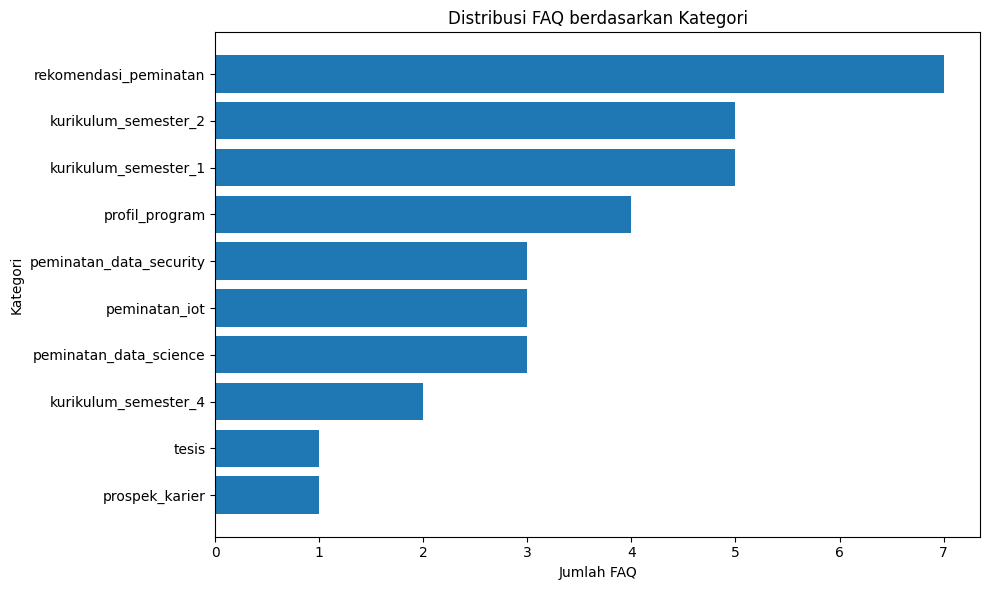

In [4]:
category_distribution = faq_df['category'].value_counts().sort_values()
display(category_distribution.reset_index().rename(columns={'index': 'category', 'category': 'count'}))

plt.figure(figsize=(10, 6))
plt.barh(category_distribution.index, category_distribution.values)
plt.title('Distribusi FAQ berdasarkan Kategori')
plt.xlabel('Jumlah FAQ')
plt.ylabel('Kategori')
plt.tight_layout()
plt.savefig(FIGURE_DIR / '01_faq_category_distribution.png', dpi=160)
plt.show()

## 4. Validasi Dataset Evaluation Questions

Dataset evaluasi perlu divalidasi agar kategori ekspektasi sesuai dengan kategori FAQ atau fallback. Coverage kategori juga penting karena evaluasi yang terlalu kecil dapat menghasilkan akurasi yang tampak tinggi tetapi tidak representatif.

In [5]:
REQUIRED_EVAL_COLUMNS = ['test_question', 'expected_category']

def validate_evaluation_dataset(eval_data: pd.DataFrame, faq_data: pd.DataFrame) -> pd.DataFrame:
    checks = []
    missing_columns = [col for col in REQUIRED_EVAL_COLUMNS if col not in eval_data.columns]
    checks.append({
        'check': 'required_columns',
        'status': 'PASS' if not missing_columns else 'FAIL',
        'detail': str(missing_columns)
    })

    if missing_columns:
        return pd.DataFrame(checks)

    allowed_categories = set(faq_data['category'].astype(str).unique()) | {'fallback'}
    invalid_categories = sorted(set(eval_data['expected_category'].astype(str).unique()) - allowed_categories)
    empty_test_question = int((eval_data['test_question'].astype(str).str.strip() == '').sum())
    duplicate_test_question = int(eval_data['test_question'].astype(str).str.lower().str.strip().duplicated().sum())
    coverage = eval_data['expected_category'].nunique() / max(1, len(allowed_categories))

    checks.extend([
        {'check': 'total_rows', 'status': 'INFO', 'detail': str(len(eval_data))},
        {'check': 'empty_test_question', 'status': 'PASS' if empty_test_question == 0 else 'FAIL', 'detail': str(empty_test_question)},
        {'check': 'duplicate_test_question', 'status': 'PASS' if duplicate_test_question == 0 else 'WARNING', 'detail': str(duplicate_test_question)},
        {'check': 'invalid_expected_category', 'status': 'PASS' if not invalid_categories else 'FAIL', 'detail': str(invalid_categories)},
        {'check': 'evaluation_category_coverage', 'status': 'PASS' if coverage >= 0.80 else 'WARNING', 'detail': f'{coverage:.2%}'},
    ])
    return pd.DataFrame(checks)

eval_validation = validate_evaluation_dataset(eval_df, faq_df)
eval_validation.to_csv(OUTPUT_DIR / 'evaluation_questions_validation_summary.csv', index=False)
display(eval_validation)

,check,status,detail
0,required_columns,PASS,[]
1,total_rows,INFO,7
2,empty_test_question,PASS,0
3,duplicate_test_question,PASS,0
4,invalid_expected_category,PASS,[]
5,evaluation_category_coverage,WARNING,45.45%


### Interpretasi Validasi Dataset Evaluasi

Dataset evaluasi valid secara struktur, tetapi jumlahnya masih sangat kecil. Dengan hanya 7 pertanyaan uji, hasil evaluasi harus dianggap sebagai evaluasi awal. Untuk tugas final, dataset ini sebaiknya diperluas minimal menjadi 30–50 pertanyaan uji yang mencakup seluruh kategori FAQ dan pertanyaan out-of-scope.

## 5. Membangun Engine TF-IDF dan Cosine Similarity

Tahap ini sama dengan baseline Tahap 01, yaitu mengubah pertanyaan FAQ menjadi representasi numerik TF-IDF, kemudian mengukur kemiripan pertanyaan pengguna dengan FAQ menggunakan cosine similarity.

In [6]:
def preprocess_text(text: str) -> str:
    text = str(text).lower()
    text = re.sub(r'[^a-z0-9\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

vectorizer = TfidfVectorizer(
    preprocessor=preprocess_text,
    ngram_range=(1, 2),
    min_df=1,
    token_pattern=r'(?u)\b\w+\b'
)

tfidf_matrix = vectorizer.fit_transform(faq_df['question'])

print('Jumlah FAQ:', len(faq_df))
print('Jumlah fitur TF-IDF:', len(vectorizer.get_feature_names_out()))
print('Shape TF-IDF matrix:', tfidf_matrix.shape)

Jumlah FAQ: 34
Jumlah fitur TF-IDF: 208
Shape TF-IDF matrix: (34, 208)


## 6. Fungsi Response dan Evaluasi Chatbot

Fungsi `get_chatbot_response()` mengembalikan kategori jawaban berdasarkan skor similarity tertinggi. Jika skor tertinggi lebih kecil dari threshold, sistem mengembalikan kategori `fallback`.

In [7]:
def get_chatbot_response(user_question: str, threshold: float = 0.25) -> dict:
    if not str(user_question).strip():
        return {
            'answer': 'Silakan masukkan pertanyaan terlebih dahulu.',
            'category': 'empty_input',
            'similarity_score': 0.0,
            'matched_question': '',
            'status': 'empty'
        }

    user_vector = vectorizer.transform([user_question])
    similarity_scores = cosine_similarity(user_vector, tfidf_matrix).flatten()
    best_index = int(similarity_scores.argmax())
    best_score = float(similarity_scores[best_index])

    if best_score < threshold:
        return {
            'answer': 'Maaf, saya belum memiliki informasi yang cukup untuk menjawab pertanyaan tersebut.',
            'category': 'fallback',
            'similarity_score': round(best_score, 4),
            'matched_question': faq_df.iloc[best_index]['question'],
            'status': 'fallback'
        }

    selected = faq_df.iloc[best_index]
    return {
        'answer': selected['answer'],
        'category': selected['category'],
        'similarity_score': round(best_score, 4),
        'matched_question': selected['question'],
        'status': 'answered'
    }


def evaluate_questions(eval_data: pd.DataFrame, threshold: float = 0.25) -> pd.DataFrame:
    records = []
    for _, row in eval_data.iterrows():
        result = get_chatbot_response(row['test_question'], threshold=threshold)
        predicted_category = result['category']
        expected_category = row['expected_category']
        records.append({
            'test_question': row['test_question'],
            'expected_category': expected_category,
            'predicted_category': predicted_category,
            'similarity_score': result['similarity_score'],
            'status': result['status'],
            'is_correct': expected_category == predicted_category,
            'matched_question': result['matched_question']
        })
    return pd.DataFrame(records)


def add_error_type(eval_result: pd.DataFrame) -> pd.DataFrame:
    result = eval_result.copy()
    error_types = []
    for _, row in result.iterrows():
        if row['is_correct']:
            error_types.append('correct')
        elif row['expected_category'] == 'fallback' and row['predicted_category'] != 'fallback':
            error_types.append('false_positive_out_of_scope')
        elif row['expected_category'] != 'fallback' and row['predicted_category'] == 'fallback':
            error_types.append('false_fallback_in_scope')
        else:
            error_types.append('wrong_category')
    result['error_type'] = error_types
    return result

## 7. Evaluasi Baseline pada Threshold 0.25

Threshold 0.25 digunakan sebagai baseline awal dari Tahap 01. Evaluasi dilakukan dengan membandingkan kategori prediksi chatbot terhadap kategori ekspektasi pada `evaluation_questions.csv`.

In [8]:
baseline_threshold = 0.25
baseline_result = add_error_type(evaluate_questions(eval_df, threshold=baseline_threshold))
baseline_accuracy = baseline_result['is_correct'].mean()

baseline_result.to_csv(OUTPUT_DIR / 'evaluation_result_threshold_0_25.csv', index=False)

print(f'Baseline threshold: {baseline_threshold}')
print(f'Baseline accuracy: {baseline_accuracy:.2%}')
print(f"Jumlah benar: {baseline_result['is_correct'].sum()} dari {len(baseline_result)}")

display(baseline_result)

Baseline threshold: 0.25
Baseline accuracy: 71.43%
Jumlah benar: 5 dari 7


,test_question,expected_category,predicted_category,similarity_score,status,is_correct,matched_question,error_type
0,Mata kuliah semester satu apa saja?,kurikulum_semester_1,kurikulum_semester_1,0.6447,answered,True,Apa saja mata kuliah Semester 1 MTI UNPAM?,correct
1,Kalau saya suka cyber security cocoknya peminatan apa?,rekomendasi_peminatan,rekomendasi_peminatan,0.3261,answered,True,"Saya tertarik keamanan siber, cocok ambil peminatan apa?",correct
2,Peminatan data science belajar apa?,peminatan_data_science,peminatan_data_science,0.7014,answered,True,Apa fokus peminatan Data Science?,correct
3,Apa perbedaan IoT dan data science?,rekomendasi_peminatan,rekomendasi_peminatan,0.7071,answered,True,Apa perbedaan peminatan Data Security dan Data Science?,correct
4,Semester empat ada mata kuliah apa?,kurikulum_semester_4,kurikulum_semester_4,0.5183,answered,True,Apa mata kuliah Semester 4 MTI UNPAM?,correct
5,"Saya suka memasak nasi goreng, apa resepnya?",fallback,rekomendasi_peminatan,0.2559,answered,False,"Saya tertarik keamanan siber, cocok ambil peminatan apa?",false_positive_out_of_scope
6,Berapa harga biaya kuliah terbaru?,fallback,peminatan_iot,0.3040,answered,False,Apa saja mata kuliah peminatan IoT?,false_positive_out_of_scope


### Interpretasi Evaluasi Baseline

Pada threshold 0.25, chatbot masih melakukan kesalahan terutama pada pertanyaan yang sebenarnya berada di luar konteks MTI UNPAM. Ini menunjukkan bahwa threshold terlalu permisif untuk sebagian pertanyaan out-of-scope.

Jumlah pertanyaan gagal: 2


,test_question,expected_category,predicted_category,similarity_score,matched_question,error_type
5,"Saya suka memasak nasi goreng, apa resepnya?",fallback,rekomendasi_peminatan,0.2559,"Saya tertarik keamanan siber, cocok ambil peminatan apa?",false_positive_out_of_scope
6,Berapa harga biaya kuliah terbaru?,fallback,peminatan_iot,0.3040,Apa saja mata kuliah peminatan IoT?,false_positive_out_of_scope


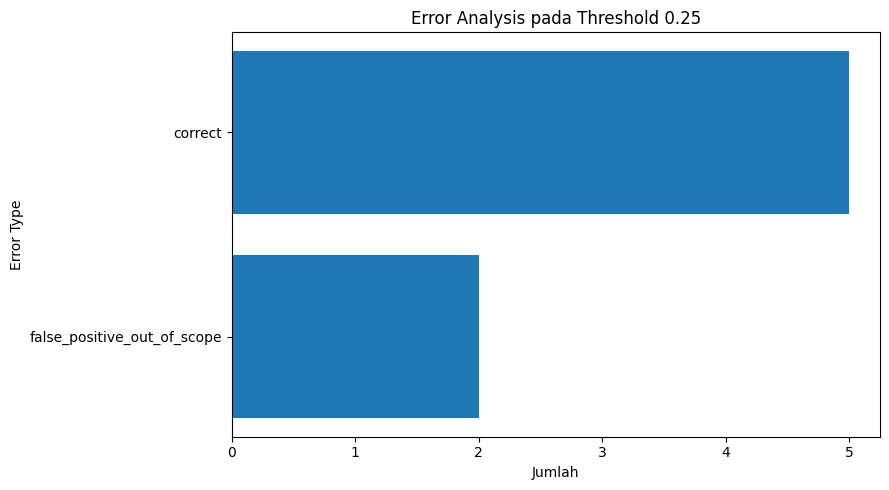

In [9]:
error_rows = baseline_result[~baseline_result['is_correct']]
print('Jumlah pertanyaan gagal:', len(error_rows))
display(error_rows[['test_question', 'expected_category', 'predicted_category', 'similarity_score', 'matched_question', 'error_type']])

error_counts = baseline_result['error_type'].value_counts().sort_values()
plt.figure(figsize=(9, 5))
plt.barh(error_counts.index, error_counts.values)
plt.title('Error Analysis pada Threshold 0.25')
plt.xlabel('Jumlah')
plt.ylabel('Error Type')
plt.tight_layout()
plt.savefig(FIGURE_DIR / '05_error_analysis_threshold_0_25.png', dpi=160)
plt.show()

## 8. Visualisasi Similarity Score Pertanyaan Uji

Visualisasi ini membantu melihat pertanyaan mana yang memiliki skor similarity rendah atau tinggi. Pertanyaan out-of-scope seharusnya memiliki skor di bawah threshold.

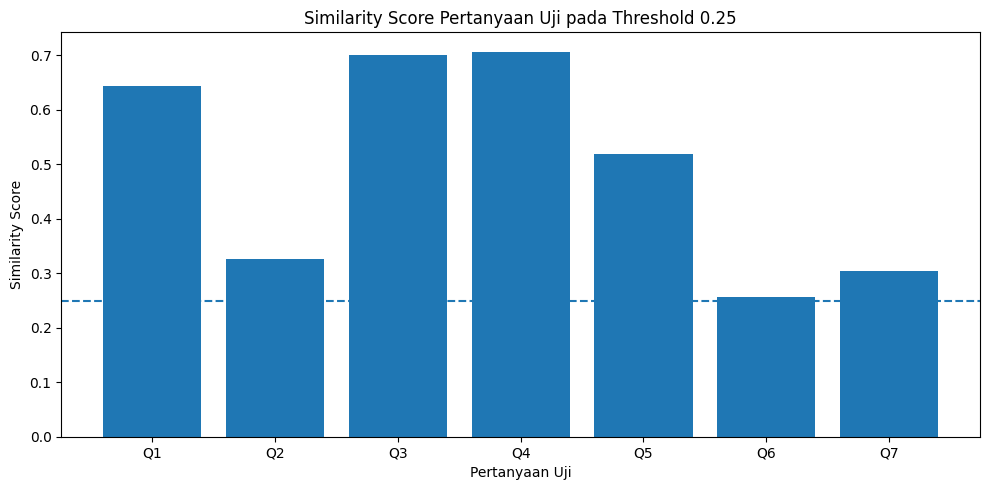

,test_question,similarity_score,expected_category,predicted_category,is_correct
0,Mata kuliah semester satu apa saja?,0.6447,kurikulum_semester_1,kurikulum_semester_1,True
1,Kalau saya suka cyber security cocoknya peminatan apa?,0.3261,rekomendasi_peminatan,rekomendasi_peminatan,True
2,Peminatan data science belajar apa?,0.7014,peminatan_data_science,peminatan_data_science,True
3,Apa perbedaan IoT dan data science?,0.7071,rekomendasi_peminatan,rekomendasi_peminatan,True
4,Semester empat ada mata kuliah apa?,0.5183,kurikulum_semester_4,kurikulum_semester_4,True
5,"Saya suka memasak nasi goreng, apa resepnya?",0.2559,fallback,rekomendasi_peminatan,False
6,Berapa harga biaya kuliah terbaru?,0.3040,fallback,peminatan_iot,False


In [10]:
plt.figure(figsize=(10, 5))
plt.bar(range(len(baseline_result)), baseline_result['similarity_score'])
plt.axhline(baseline_threshold, linestyle='--')
plt.xticks(range(len(baseline_result)), [f'Q{i+1}' for i in range(len(baseline_result))])
plt.title('Similarity Score Pertanyaan Uji pada Threshold 0.25')
plt.xlabel('Pertanyaan Uji')
plt.ylabel('Similarity Score')
plt.tight_layout()
plt.savefig(FIGURE_DIR / '03_similarity_scores_threshold_0_25.png', dpi=160)
plt.show()

display(baseline_result[['test_question', 'similarity_score', 'expected_category', 'predicted_category', 'is_correct']])

## 9. Threshold Tuning

Threshold tuning dilakukan dengan mencoba beberapa nilai threshold dari 0.05 sampai 0.80. Tujuannya mencari threshold yang paling baik dalam membedakan pertanyaan in-scope dan out-of-scope pada dataset evaluasi saat ini.

In [11]:
threshold_values = np.round(np.arange(0.05, 0.801, 0.005), 3)
threshold_records = []

for threshold in threshold_values:
    result = add_error_type(evaluate_questions(eval_df, threshold=float(threshold)))
    expected_fallback = result['expected_category'].eq('fallback')
    predicted_fallback = result['predicted_category'].eq('fallback')

    threshold_records.append({
        'threshold': float(threshold),
        'accuracy': result['is_correct'].mean(),
        'correct': int(result['is_correct'].sum()),
        'total': int(len(result)),
        'false_positive_out_of_scope': int((expected_fallback & ~predicted_fallback).sum()),
        'false_fallback_in_scope': int((~expected_fallback & predicted_fallback).sum()),
        'answered_count': int(result['status'].eq('answered').sum()),
        'fallback_count': int(result['status'].eq('fallback').sum()),
    })

threshold_result = pd.DataFrame(threshold_records)
threshold_result.to_csv(OUTPUT_DIR / 'threshold_tuning_results.csv', index=False)

max_accuracy = threshold_result['accuracy'].max()
best_thresholds = threshold_result[threshold_result['accuracy'] == max_accuracy]['threshold'].tolist()
recommended_threshold = 0.31 if 0.31 in best_thresholds else best_thresholds[len(best_thresholds)//2]

print(f'Max accuracy: {max_accuracy:.2%}')
print(f'Best threshold range: {min(best_thresholds):.3f} - {max(best_thresholds):.3f}')
print(f'Recommended temporary threshold: {recommended_threshold:.3f}')

display(threshold_result.sort_values(['accuracy', 'threshold'], ascending=[False, True]).head(10))

Max accuracy: 100.00%
Best threshold range: 0.305 - 0.325
Recommended temporary threshold: 0.310


,threshold,accuracy,correct,total,false_positive_out_of_scope,false_fallback_in_scope,answered_count,fallback_count
51,0.305,1.000000,7,7,0,0,5,2
52,0.310,1.000000,7,7,0,0,5,2
53,0.315,1.000000,7,7,0,0,5,2
54,0.320,1.000000,7,7,0,0,5,2
55,0.325,1.000000,7,7,0,0,5,2
42,0.260,0.857143,6,7,1,0,6,1
43,0.265,0.857143,6,7,1,0,6,1
44,0.270,0.857143,6,7,1,0,6,1
45,0.275,0.857143,6,7,1,0,6,1
46,0.280,0.857143,6,7,1,0,6,1


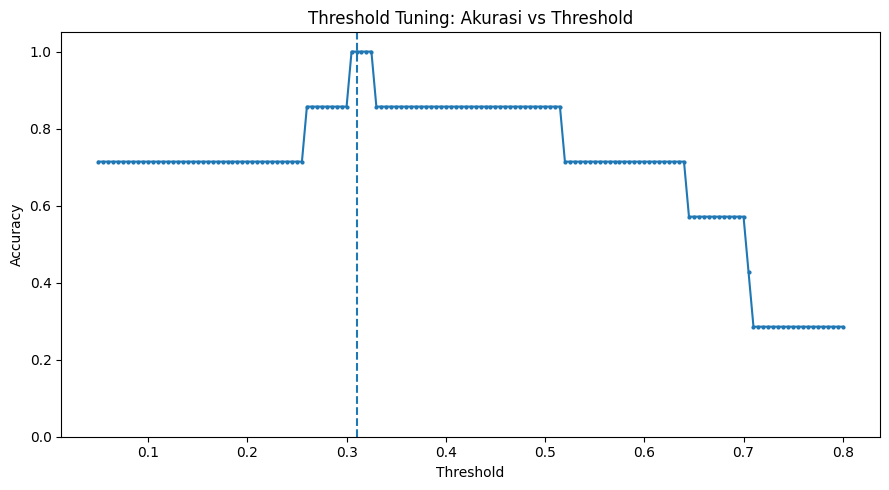

In [12]:
plt.figure(figsize=(9, 5))
plt.plot(threshold_result['threshold'], threshold_result['accuracy'], marker='o', markersize=2)
plt.axvline(recommended_threshold, linestyle='--')
plt.title('Threshold Tuning: Akurasi vs Threshold')
plt.xlabel('Threshold')
plt.ylabel('Accuracy')
plt.ylim(0, 1.05)
plt.tight_layout()
plt.savefig(FIGURE_DIR / '02_threshold_tuning_accuracy.png', dpi=160)
plt.show()

### Interpretasi Threshold Tuning

Threshold yang terlalu rendah membuat chatbot menjawab pertanyaan yang seharusnya masuk fallback. Threshold yang terlalu tinggi membuat pertanyaan valid justru jatuh ke fallback. Berdasarkan dataset evaluasi saat ini, threshold sekitar 0.31 menjadi rekomendasi sementara karena dapat menekan false positive pada pertanyaan out-of-scope tanpa mengorbankan pertanyaan valid.

## 10. Evaluasi pada Threshold Rekomendasi

Bagian ini mengevaluasi kembali chatbot menggunakan threshold rekomendasi sementara. Hasil ini dibandingkan dengan baseline threshold 0.25.

In [13]:
recommended_result = add_error_type(evaluate_questions(eval_df, threshold=recommended_threshold))
recommended_accuracy = recommended_result['is_correct'].mean()
recommended_result.to_csv(OUTPUT_DIR / 'evaluation_result_recommended_threshold.csv', index=False)

print(f'Recommended threshold: {recommended_threshold:.3f}')
print(f'Recommended threshold accuracy: {recommended_accuracy:.2%}')
print(f"Jumlah benar: {recommended_result['is_correct'].sum()} dari {len(recommended_result)}")

display(recommended_result)

Recommended threshold: 0.310
Recommended threshold accuracy: 100.00%
Jumlah benar: 7 dari 7


,test_question,expected_category,predicted_category,similarity_score,status,is_correct,matched_question,error_type
0,Mata kuliah semester satu apa saja?,kurikulum_semester_1,kurikulum_semester_1,0.6447,answered,True,Apa saja mata kuliah Semester 1 MTI UNPAM?,correct
1,Kalau saya suka cyber security cocoknya peminatan apa?,rekomendasi_peminatan,rekomendasi_peminatan,0.3261,answered,True,"Saya tertarik keamanan siber, cocok ambil peminatan apa?",correct
2,Peminatan data science belajar apa?,peminatan_data_science,peminatan_data_science,0.7014,answered,True,Apa fokus peminatan Data Science?,correct
3,Apa perbedaan IoT dan data science?,rekomendasi_peminatan,rekomendasi_peminatan,0.7071,answered,True,Apa perbedaan peminatan Data Security dan Data Science?,correct
4,Semester empat ada mata kuliah apa?,kurikulum_semester_4,kurikulum_semester_4,0.5183,answered,True,Apa mata kuliah Semester 4 MTI UNPAM?,correct
5,"Saya suka memasak nasi goreng, apa resepnya?",fallback,fallback,0.2559,fallback,True,"Saya tertarik keamanan siber, cocok ambil peminatan apa?",correct
6,Berapa harga biaya kuliah terbaru?,fallback,fallback,0.3040,fallback,True,Apa saja mata kuliah peminatan IoT?,correct


## 11. Classification Report dan Confusion Matrix

Classification report digunakan untuk melihat precision, recall, dan F1-score per kategori. Karena jumlah data evaluasi masih sangat kecil, metrik ini hanya digunakan sebagai indikasi awal, bukan klaim performa final.

,precision,recall,f1-score,support
fallback,1.0,1.0,1.0,2.0
kurikulum_semester_1,1.0,1.0,1.0,1.0
kurikulum_semester_4,1.0,1.0,1.0,1.0
peminatan_data_science,1.0,1.0,1.0,1.0
rekomendasi_peminatan,1.0,1.0,1.0,2.0
accuracy,1.0,1.0,1.0,1.0
macro avg,1.0,1.0,1.0,7.0
weighted avg,1.0,1.0,1.0,7.0


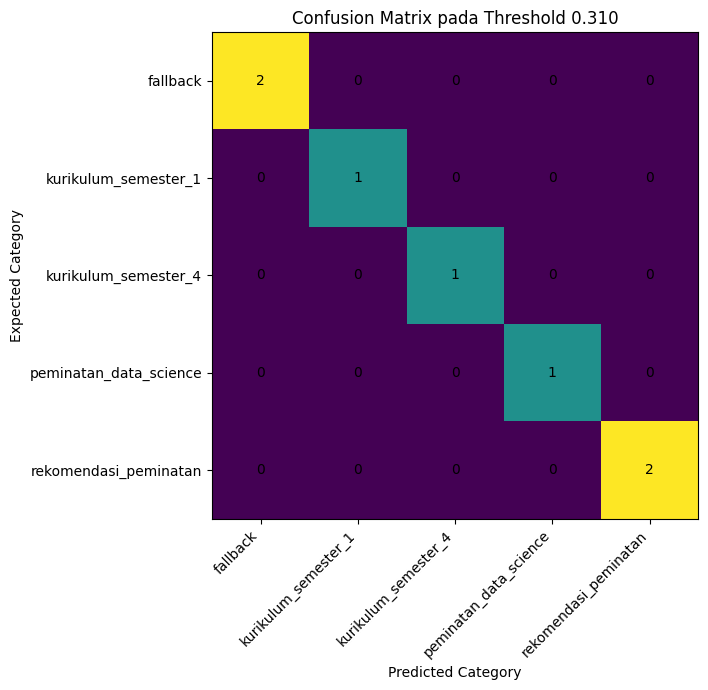

In [14]:
labels = sorted(set(recommended_result['expected_category']) | set(recommended_result['predicted_category']))
report = classification_report(
    recommended_result['expected_category'],
    recommended_result['predicted_category'],
    labels=labels,
    zero_division=0,
    output_dict=True
)
report_df = pd.DataFrame(report).transpose()
report_df.to_csv(OUTPUT_DIR / 'classification_report_recommended_threshold.csv')
display(report_df)

cm = confusion_matrix(recommended_result['expected_category'], recommended_result['predicted_category'], labels=labels)

plt.figure(figsize=(9, 7))
plt.imshow(cm)
plt.title(f'Confusion Matrix pada Threshold {recommended_threshold:.3f}')
plt.xticks(range(len(labels)), labels, rotation=45, ha='right')
plt.yticks(range(len(labels)), labels)
plt.xlabel('Predicted Category')
plt.ylabel('Expected Category')
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha='center', va='center')
plt.tight_layout()
plt.savefig(FIGURE_DIR / '04_confusion_matrix_recommended_threshold.png', dpi=160)
plt.show()

## 12. Perbandingan Baseline dan Threshold Rekomendasi

Tabel berikut membandingkan akurasi baseline dengan akurasi setelah threshold tuning.

In [15]:
comparison_df = pd.DataFrame([
    {
        'scenario': 'Baseline',
        'threshold': baseline_threshold,
        'accuracy': baseline_accuracy,
        'correct': int(baseline_result['is_correct'].sum()),
        'total': len(baseline_result)
    },
    {
        'scenario': 'After threshold tuning',
        'threshold': recommended_threshold,
        'accuracy': recommended_accuracy,
        'correct': int(recommended_result['is_correct'].sum()),
        'total': len(recommended_result)
    }
])

display(comparison_df)
comparison_df.to_csv(OUTPUT_DIR / 'baseline_vs_tuned_threshold_comparison.csv', index=False)

,scenario,threshold,accuracy,correct,total
0,Baseline,0.25,0.714286,5,7
1,After threshold tuning,0.31,1.000000,7,7


## 13. Rekomendasi Perbaikan Dataset dan Chatbot

Berdasarkan validasi dan error analysis, rekomendasi perbaikan adalah sebagai berikut:

1. Tambahkan variasi pertanyaan pada setiap kategori FAQ, terutama kategori yang hanya memiliki 1 data seperti `tesis` dan `prospek_karier`.
2. Perluas `evaluation_questions.csv` dari 7 pertanyaan menjadi minimal 30–50 pertanyaan uji.
3. Tambahkan pertanyaan out-of-scope yang lebih beragam, misalnya biaya kuliah, pendaftaran, resep makanan, jadwal kampus, lokasi, dan pertanyaan umum non-akademik.
4. Tambahkan stopwords Bahasa Indonesia sederhana agar kata umum seperti `saya`, `apa`, `yang`, `dan`, `di`, `ke`, `untuk`, `suka` tidak terlalu dominan dalam similarity.
5. Tambahkan metadata sumber jawaban yang lebih eksplisit, terutama jika informasi berasal dari website resmi, RPS, atau sumber manual.
6. Gunakan threshold rekomendasi 0.31 sebagai nilai sementara pada aplikasi Streamlit, tetapi lakukan evaluasi ulang setelah dataset evaluasi diperluas.
7. Untuk tahap berikutnya, pertimbangkan penambahan intent classification sederhana atau hybrid rule + TF-IDF agar fallback lebih stabil.

## 14. Kesimpulan Tahap 02

Tahap 02 menunjukkan bahwa chatbot baseline sudah dapat menjawab sebagian besar pertanyaan evaluasi, tetapi masih memiliki risiko false positive pada pertanyaan out-of-scope. Threshold tuning memberikan rekomendasi sementara sekitar 0.31, yang lebih baik daripada threshold awal 0.25 pada dataset evaluasi saat ini. Namun, karena dataset evaluasi masih kecil, langkah paling penting berikutnya adalah memperluas dataset FAQ dan evaluation questions agar evaluasi menjadi lebih kuat dan tidak bias.